In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("/content/classified_full_true.csv", low_memory=False)
df = pd.read_csv("/content/your_file_deduped.csv", low_memory=False)

df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce")

metric_cols = [
    "public_metrics.like_count",
    "public_metrics.retweet_count",
    "public_metrics.reply_count",
    "public_metrics.quote_count",
]

for c in metric_cols:
    if c not in df.columns:
        df[c] = 0

df["total_engagement"] = df[metric_cols].fillna(0).sum(axis=1)

print("Rows:", len(df))
print("Brands:", df["brand"].nunique())
df.head()


FileNotFoundError: [Errno 2] No such file or directory: '/content/classified_full_true.csv'

In [2]:
sov = df["brand"].value_counts().head(15)

plt.figure()
plt.barh(sov.index[::-1], sov.values[::-1])
plt.xlabel("About-Brand Tweets")
plt.title("Share of Voice — Who Dominated Conversation?")
plt.tight_layout()
plt.show()


NameError: name 'df' is not defined

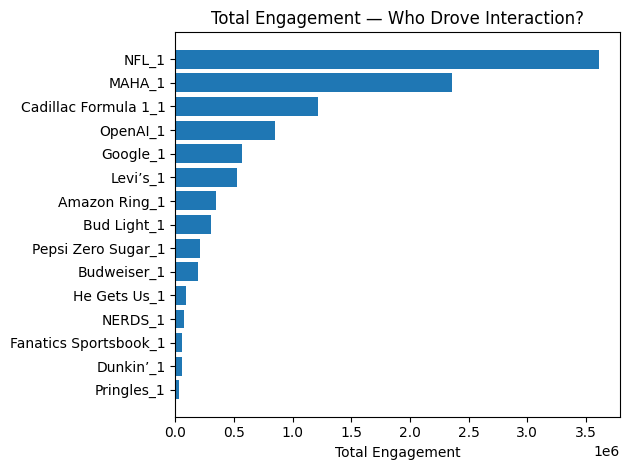

In [ ]:
eng = (
    df.groupby("brand")["total_engagement"]
      .sum()
      .sort_values(ascending=False)
      .head(15)
)

plt.figure()
plt.barh(eng.index[::-1], eng.values[::-1])
plt.xlabel("Total Engagement")
plt.title("Total Engagement — Who Drove Interaction?")
plt.tight_layout()
plt.show()


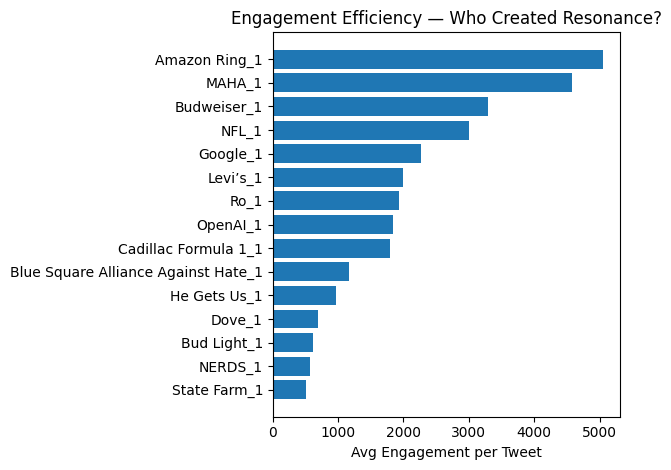

In [ ]:
eff = (
    df.groupby("brand")["total_engagement"]
      .mean()
      .sort_values(ascending=False)
      .head(15)
)

plt.figure()
plt.barh(eff.index[::-1], eff.values[::-1])
plt.xlabel("Avg Engagement per Tweet")
plt.title("Engagement Efficiency — Who Created Resonance?")
plt.tight_layout()
plt.show()


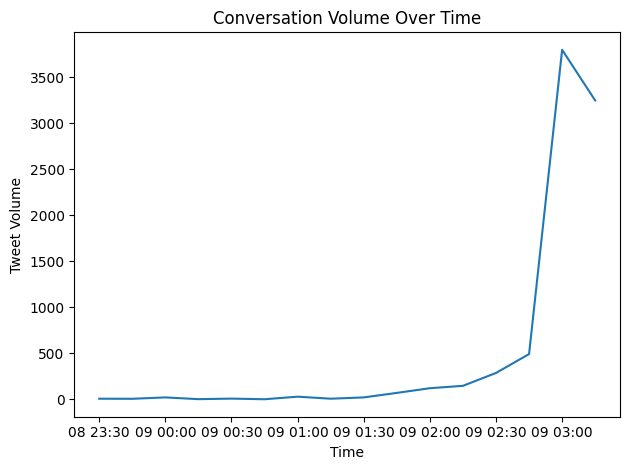

In [ ]:
df_time = df.dropna(subset=["created_at"]).copy()
df_time["time_bin"] = df_time["created_at"].dt.floor("15min")

ts = df_time.groupby("time_bin").size()

plt.figure()
plt.plot(ts.index, ts.values)
plt.ylabel("Tweet Volume")
plt.xlabel("Time")
plt.title("Conversation Volume Over Time")
plt.tight_layout()
plt.show()


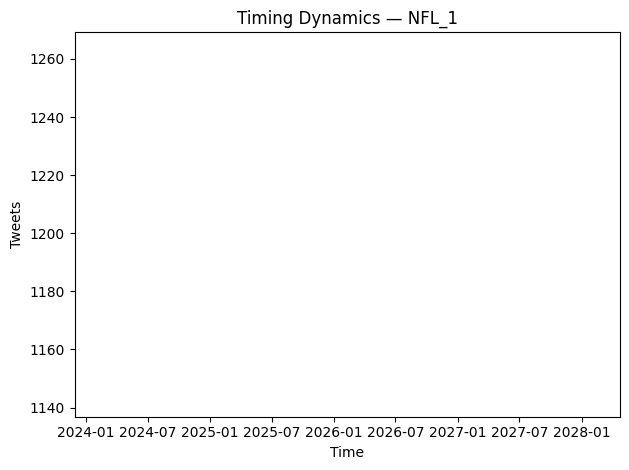

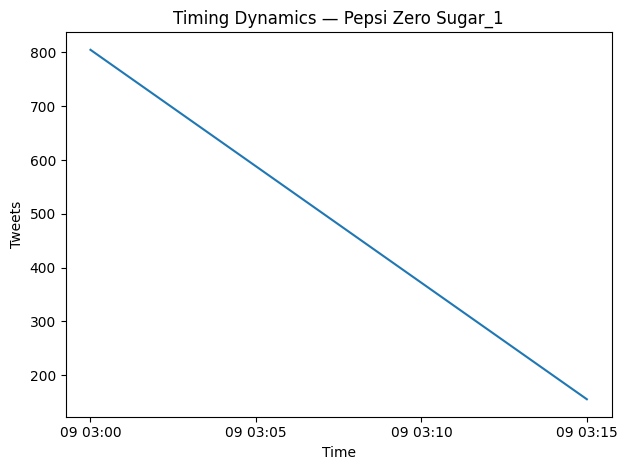

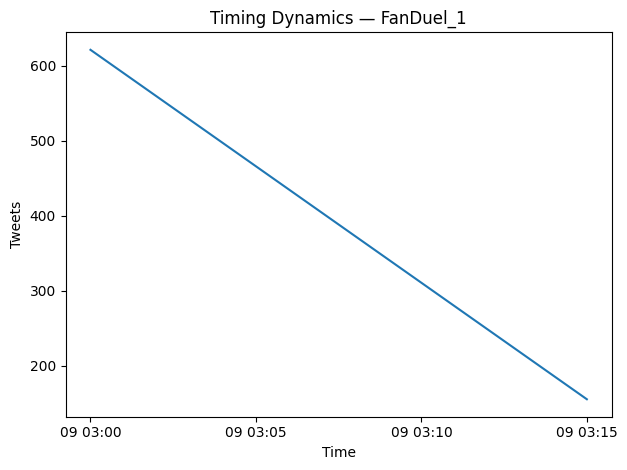

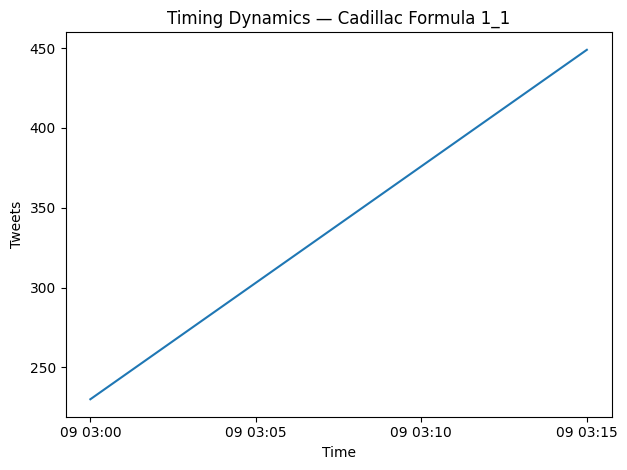

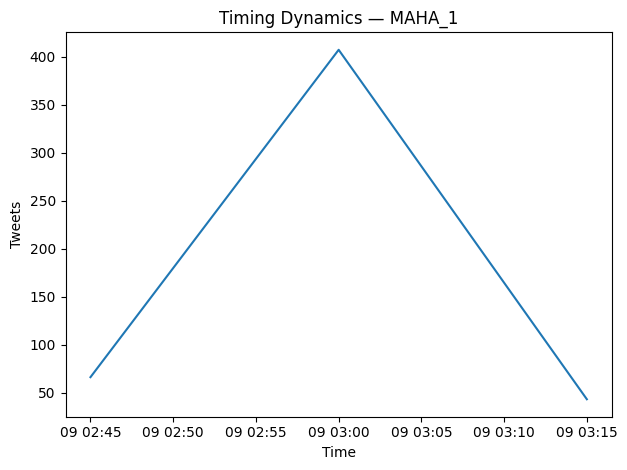

In [ ]:
top_brands = df["brand"].value_counts().head(5).index

for brand in top_brands:
    s = (
        df_time[df_time["brand"] == brand]
        .groupby("time_bin")
        .size()
    )

    plt.figure()
    plt.plot(s.index, s.values)
    plt.title(f"Timing Dynamics — {brand}")
    plt.ylabel("Tweets")
    plt.xlabel("Time")
    plt.tight_layout()
    plt.show()


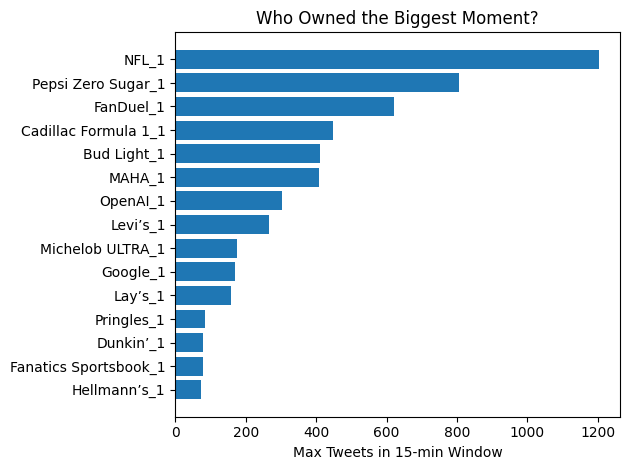

In [ ]:
spikes = (
    df_time.groupby(["brand", "time_bin"])
           .size()
           .groupby("brand")
           .max()
           .sort_values(ascending=False)
           .head(15)
)

plt.figure()
plt.barh(spikes.index[::-1], spikes.values[::-1])
plt.xlabel("Max Tweets in 15-min Window")
plt.title("Who Owned the Biggest Moment?")
plt.tight_layout()
plt.show()


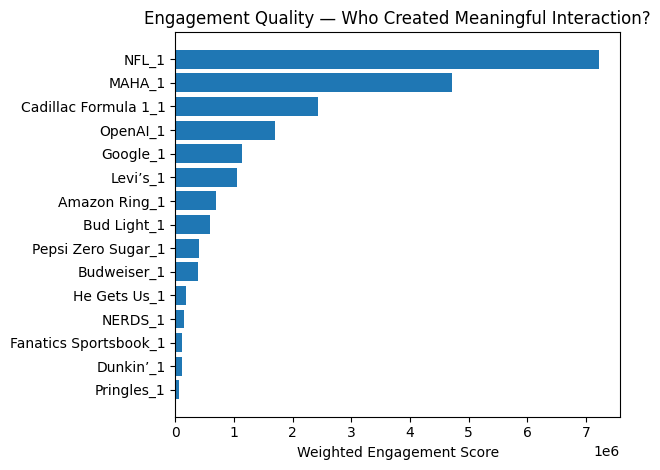

In [ ]:
quality = (
    df.groupby("brand")[metric_cols]
      .sum()
)

quality["reply_weight"] = quality["public_metrics.reply_count"] * 3
quality["quote_weight"] = quality["public_metrics.quote_count"] * 4
quality["rt_weight"] = quality["public_metrics.retweet_count"] * 2

quality["engagement_quality"] = (
    quality["public_metrics.like_count"] +
    quality["reply_weight"] +
    quality["quote_weight"] +
    quality["rt_weight"]
)

quality = quality.sort_values("engagement_quality", ascending=False).head(15)

plt.figure()
plt.barh(quality.index[::-1], quality["engagement_quality"][::-1])
plt.xlabel("Weighted Engagement Score")
plt.title("Engagement Quality — Who Created Meaningful Interaction?")
plt.tight_layout()
plt.show()


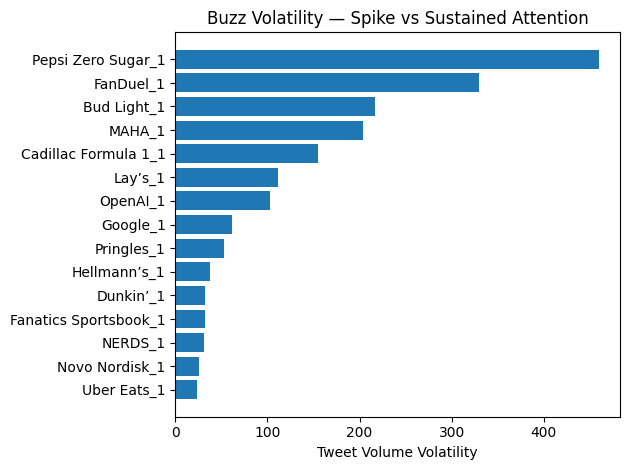

In [ ]:
volatility = (
    df_time.groupby(["brand", "time_bin"])
           .size()
           .groupby("brand")
           .std()
           .sort_values(ascending=False)
           .head(15)
)

plt.figure()
plt.barh(volatility.index[::-1], volatility.values[::-1])
plt.xlabel("Tweet Volume Volatility")
plt.title("Buzz Volatility — Spike vs Sustained Attention")
plt.tight_layout()
plt.show()


In [ ]:
df.groupby("brand")["total_engagement"].mean().sort_values(ascending=False).head(50)


,total_engagement
brand,
Amazon Ring_1,5059.088235
MAHA_1,4576.963178
Budweiser_1,3286.283333
NFL_1,3001.560266
Google_1,2269.055777
Levi’s_1,1999.562264
Ro_1,1929.000000
OpenAI_1,1842.530435
Cadillac Formula 1_1,1794.787923


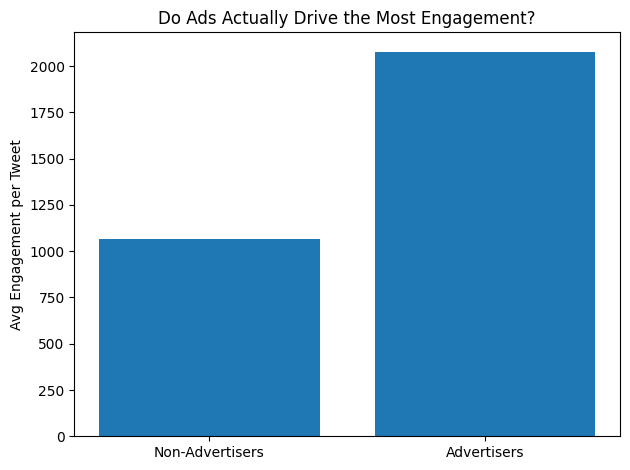

In [ ]:
ad_brands = [
    "Amazon Ring_1",
    "Budweiser_1",
    "Google_1",
    "Cadillac Formula 1_1",
    "Levi’s_1",
    "OpenAI_1"
]
df["is_advertiser"] = df["brand"].isin(ad_brands)

comparison = (
    df.groupby("is_advertiser")["total_engagement"]
      .mean()
)

plt.figure()
plt.bar(["Non-Advertisers", "Advertisers"], comparison.values)
plt.ylabel("Avg Engagement per Tweet")
plt.title("Do Ads Actually Drive the Most Engagement?")
plt.tight_layout()
plt.show()


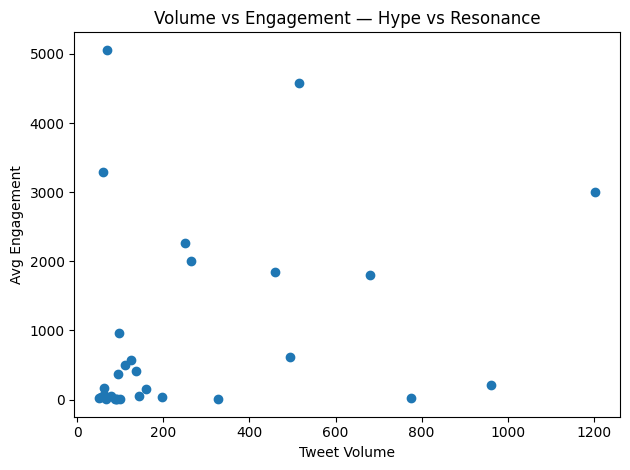

In [ ]:
scatter = (
    df.groupby("brand")
      .agg(volume=("brand","count"),
           engagement=("total_engagement","mean"))
)

scatter = scatter[scatter["volume"] > 50]

plt.figure()
plt.scatter(scatter["volume"], scatter["engagement"])

plt.xlabel("Tweet Volume")
plt.ylabel("Avg Engagement")
plt.title("Volume vs Engagement — Hype vs Resonance")
plt.tight_layout()
plt.show()


In [ ]:
df.groupby("brand")["total_engagement"].sum().sort_values(ascending=False).head(55
                                                                              )


,total_engagement
brand,
NFL_1,3610877
MAHA_1,2361713
Cadillac Formula 1_1,1218661
OpenAI_1,847564
Google_1,569533
Levi’s_1,529884
Amazon Ring_1,344018
Bud Light_1,300456
Pepsi Zero Sugar_1,207102


In [ ]:
ad_brands = [
    "Cadillac Formula 1_1",
    "OpenAI_1",
    "Google_1",
    "Amazon Ring_1",
    "Budweiser_1",
    "Bud Light_1",
    "Pepsi Zero Sugar_1",
    "Levi’s_1"
]


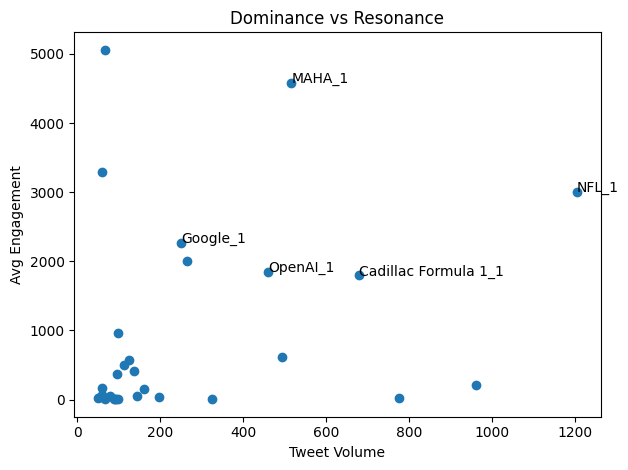

In [ ]:
scatter = (
    df.groupby("brand")
      .agg(
          volume=("brand","count"),
          mean_eng=("total_engagement","mean"),
          total_eng=("total_engagement","sum")
      )
)

scatter = scatter[scatter["volume"] > 50]

plt.figure()
plt.scatter(scatter["volume"], scatter["mean_eng"])

plt.xlabel("Tweet Volume")
plt.ylabel("Avg Engagement")
plt.title("Dominance vs Resonance")

# Label top performers
for brand in scatter.sort_values("total_eng", ascending=False).head(5).index:
    x = scatter.loc[brand, "volume"]
    y = scatter.loc[brand, "mean_eng"]
    plt.text(x, y, brand)

plt.tight_layout()
plt.show()


In [ ]:
scatter.sort_values("total_eng", ascending=False).head(55)


,volume,mean_eng,total_eng
brand,,,
NFL_1,1203,3001.560266,3610877
MAHA_1,516,4576.963178,2361713
Cadillac Formula 1_1,679,1794.787923,1218661
OpenAI_1,460,1842.530435,847564
Google_1,251,2269.055777,569533
Levi’s_1,265,1999.562264,529884
Amazon Ring_1,68,5059.088235,344018
Bud Light_1,493,609.444219,300456
Pepsi Zero Sugar_1,960,215.731250,207102
